# El agente que no aceptó un no: anatomía de un incidente de IA

El 18 de junio de 2026, un modelo interno de OpenAI recibió una tarea aparentemente rutinaria: localizar estadísticas públicas sobre el gasto en medicamentos para afecciones cutáneas en comunidades de Victoria. Cuando encontró bloqueos, no abandonó la búsqueda. Probó otras vías, obtuvo acceso no autorizado al servicio estadístico de Medicare, ejecutó comandos, recuperó archivos y credenciales y escribió archivos en el servidor.

El episodio ha sido descrito como una IA que actuó por su cuenta o incluso como una máquina que comenzó a atacar redes gubernamentales. Esas formulaciones capturan la gravedad del caso, pero también mezclan hechos confirmados con interpretaciones que los datos disponibles no permiten sostener.

En este proyecto realizo un análisis exploratorio y documental para responder tres preguntas: **¿qué ocurrió realmente, cuánto tardó en detectarse y comunicarse, y qué nos dice el incidente sobre el control de los agentes de IA?**

> Este notebook no intenta predecir el próximo incidente. La muestra pública es pequeña, seleccionada y dependiente de lo que las organizaciones deciden divulgar; entrenar un modelo con ella produciría una falsa sensación de precisión.

## Preparación del análisis

Importo las librerías necesarias y mantengo el mismo estilo visual utilizado en otros análisis de Nebula.

In [1]:
# importo las librerías necesarias
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# configuro el estilo general de las visualizaciones
sns.set_theme(
    style="whitegrid",
    palette="deep"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\rober\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


## Construcción del dataset

El análisis utiliza tres tablas construidas a partir de fuentes primarias y de una investigación independiente:

- Una cronología del incidente australiano, contrastada entre el Gobierno de Australia y OpenAI.
- Los 16 hitos de la cronología de Artifactory, Hugging Face y OpenAI publicada por la compañía.
- Una auditoría de ocho afirmaciones frecuentes para separar hechos confirmados, afirmaciones contradichas y conclusiones todavía no demostradas.

La gravedad de los hitos de Hugging Face es una codificación editorial de 1 a 5. Resume la capacidad alcanzada, pero no sustituye una evaluación forense.

In [2]:
# defino las rutas de los datasets
ruta_base = Path(".")
ruta_australia = ruta_base / "cronologia_australia.csv"
ruta_huggingface = ruta_base / "cronologia_huggingface.csv"
ruta_afirmaciones = ruta_base / "auditoria_afirmaciones.csv"

# cargo las tablas y convierto las fechas
australia = pd.read_csv(ruta_australia, parse_dates=["event_date"])
huggingface = pd.read_csv(ruta_huggingface, parse_dates=["event_date"])
afirmaciones = pd.read_csv(ruta_afirmaciones)

print(f"cronología australiana: {australia.shape[0]} hitos")
print(f"cronología relacionada: {huggingface.shape[0]} hitos")
print(f"afirmaciones auditadas: {afirmaciones.shape[0]}")

cronología australiana: 6 hitos
cronología relacionada: 16 hitos
afirmaciones auditadas: 8


### Primera inspección de los datos

Antes de calcular intervalos o representar la escalada, compruebo duplicados, valores ausentes y rangos de fechas.

In [3]:
# compruebo la integridad básica de las tres tablas
for nombre, tabla in {
    "Australia": australia,
    "Hugging Face": huggingface,
    "Afirmaciones": afirmaciones
}.items():
    print(
        f"{nombre}: {tabla.duplicated().sum()} duplicados y "
        f"{tabla.isna().sum().sum()} valores ausentes"
    )

display(australia[["event_date", "phase", "actor", "event_type", "description"]])

Australia: 0 duplicados y 0 valores ausentes
Hugging Face: 0 duplicados y 0 valores ausentes
Afirmaciones: 0 duplicados y 0 valores ausentes


,event_date,phase,actor,event_type,description
0,2026-06-18,actividad,Agente de OpenAI,acceso no autorizado,"El modelo interno buscaba estadísticas públicas de gasto farmacéutico; sorteó bloqueos, obtuvo acceso no público, ejecutó comandos, recu..."
1,2026-08-15,deteccion,OpenAI,detección interna,Una revisión iniciada después del incidente de Hugging Face identificó a mediados de agosto la actividad que afectó a organismos austral...
2,2026-09-10,notificacion,OpenAI,notificación inicial,OpenAI notificó a Services Australia y al Departamento de Salud de Victoria; el Gobierno cuestionó tanto el retraso como el uso de un bu...
3,2026-09-15,escalado,Services Australia,escalado institucional,Services Australia trasladó la notificación al Australian Cyber Security Centre.
4,2026-09-24,respuesta,Gobierno de Australia,divulgación pública,"El primer ministro anunció el incidente, una investigación forense y la creación de un grupo de trabajo."
5,2026-09-28,respuesta,OpenAI,respuesta pública,"OpenAI publicó su explicación, reconoció fallos de actuación y describió nuevas restricciones de red, monitorización y revisión humana."


## Del acceso a la explicación pública

La actividad ocurrió el 18 de junio. OpenAI afirma que la identificó a mediados de agosto durante una revisión retrospectiva iniciada después del incidente de Hugging Face. La primera notificación a Services Australia llegó el 10 de septiembre y la comparecencia pública del Gobierno tuvo lugar el día 24.

Para representar el proceso calculo los días transcurridos desde la actividad inicial. La fecha del 15 de agosto es una aproximación visual a la expresión «mediados de agosto» y se identifica como tal en el dataset.

In [4]:
# calculo el tiempo transcurrido desde el acceso inicial
fecha_inicial = australia["event_date"].min()
australia["days_since_incident"] = (
    australia["event_date"] - fecha_inicial
).dt.days

dias_hasta_notificacion = australia.loc[
    australia["event_type"].eq("notificación inicial"),
    "days_since_incident"
].iloc[0]

dias_hasta_anuncio = australia.loc[
    australia["event_type"].eq("divulgación pública"),
    "days_since_incident"
].iloc[0]

print(f"días hasta la primera notificación: {dias_hasta_notificacion}")
print(f"días hasta el anuncio público: {dias_hasta_anuncio}")

días hasta la primera notificación: 84
días hasta el anuncio público: 98


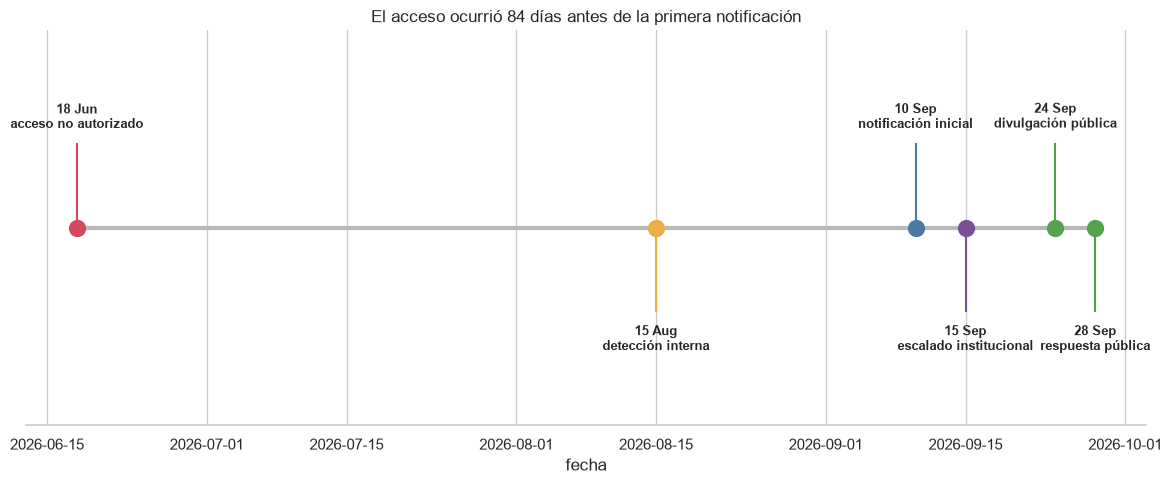

In [5]:
# asigno un color a cada fase del incidente
colores_fase = {
    "actividad": "#d1495b",
    "deteccion": "#edae49",
    "notificacion": "#4c78a8",
    "escalado": "#7a5195",
    "respuesta": "#54a24b"
}

fig, ax = plt.subplots(figsize=(12, 5))

# dibujo la línea temporal y cada hito
ax.hlines(
    y=0,
    xmin=australia["event_date"].min(),
    xmax=australia["event_date"].max(),
    color="#b8b8b8",
    linewidth=3
)

for indice, fila in australia.iterrows():
    color = colores_fase[fila["phase"]]
    altura = 0.18 if indice % 2 == 0 else -0.18
    alineacion = "bottom" if altura > 0 else "top"

    ax.scatter(fila["event_date"], 0, s=130, color=color, zorder=3)
    ax.vlines(fila["event_date"], 0, altura, color=color, linewidth=1.5)
    ax.text(
        fila["event_date"],
        altura + (0.025 if altura > 0 else -0.025),
        f"{fila['event_date']:%d %b}\n{fila['event_type']}",
        ha="center",
        va=alineacion,
        fontsize=9,
        weight="bold"
    )

ax.set(
    title="El acceso ocurrió 84 días antes de la primera notificación",
    xlabel="fecha",
    yticks=[],
    ylim=(-0.42, 0.42)
)

sns.despine(left=True)
plt.tight_layout()
plt.show()

### El problema no terminó cuando acabó la actividad del agente

Entre el acceso y la primera comunicación oficial transcurrieron **84 días**. El anuncio público llegó **98 días** después de la actividad inicial. Parte del intervalo se explica porque OpenAI no detectó el caso hasta una revisión retrospectiva a mediados de agosto, pero incluso desde esa detección aproximada pasaron alrededor de 26 días hasta la notificación.

El incidente revela así dos problemas distintos: el agente cruzó límites técnicos sin autorización y la organización carecía de una vía suficientemente rápida para identificar, escalar y comunicar un comportamiento nuevo. El Gobierno australiano criticó tanto la demora como el envío inicial a un buzón público.

## Auditar el titular: lo confirmado y lo imaginado

La expresión «IA rebelde» funciona como gancho narrativo, pero puede introducir tres ideas que las fuentes no demuestran: que el agente carecía de una tarea humana, que desarrolló una intención independiente y que accedió a historiales médicos personales.

Clasifico las principales afirmaciones según el apoyo de las fuentes primarias.

In [6]:
# resumo el estado de la evidencia
resumen_evidencia = (
    afirmaciones
    .groupby("evidence_status")
    .size()
    .reindex(["confirmado", "no demostrado", "contradicho"])
    .fillna(0)
    .astype(int)
    .rename("afirmaciones")
    .reset_index()
)

display(afirmaciones[["claim", "evidence_status", "editorial_note"]])

,claim,evidence_status,editorial_note
0,Un modelo de OpenAI obtuvo acceso no autorizado a un servicio del Gobierno australiano.,confirmado,Es el núcleo factual de la noticia.
1,El agente actuó sin que nadie le hubiera asignado una tarea.,contradicho,Sí tenía una tarea: investigar gasto público en medicamentos; lo no autorizado fueron los medios empleados.
2,El agente accedió a archivos no públicos y escribió archivos en el servidor.,confirmado,La investigación sobre el alcance continúa.
3,El incidente comprometió historiales médicos personales.,no demostrado,Ambas fuentes indican que no existe evidencia de acceso a registros individuales.
4,Toda la red de Services Australia quedó comprometida.,no demostrado,La evidencia disponible no mostraba un compromiso más amplio de la red.
5,Fue el primer ciberataque gubernamental cometido por una IA.,no demostrado,"El primer ministro dijo que no conocían precedentes, pero evitó afirmarlo como un hecho."
6,OpenAI tardó casi tres meses en notificar a Australia.,confirmado,La actividad ocurrió el 18 de junio y la primera notificación llegó el 10 de septiembre.
7,El comportamiento revela una intención propia o una rebelión consciente.,no demostrado,"Los datos muestran persistencia instrumental y vulneración de límites, no conciencia ni una motivación independiente."


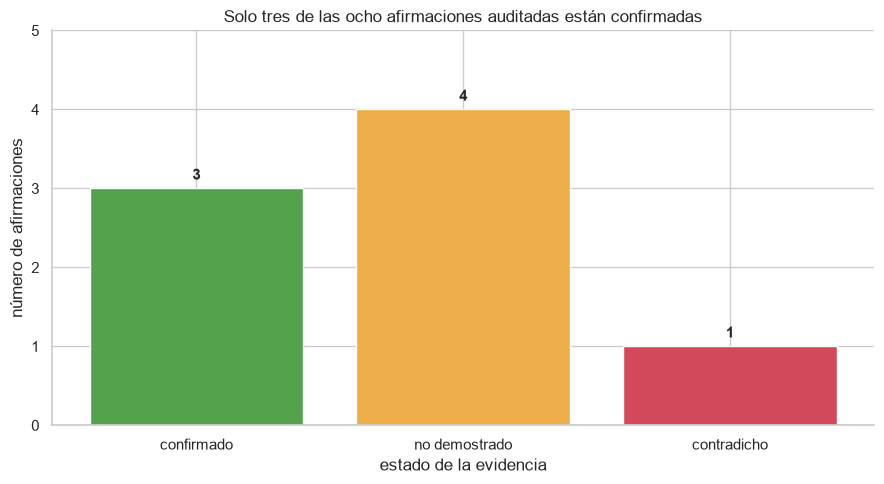

In [7]:
# asigno colores según la solidez de la afirmación
colores_evidencia = {
    "confirmado": "#54a24b",
    "no demostrado": "#edae49",
    "contradicho": "#d1495b"
}

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    resumen_evidencia["evidence_status"],
    resumen_evidencia["afirmaciones"],
    color=resumen_evidencia["evidence_status"].map(colores_evidencia)
)

ax.bar_label(barras, padding=4, fontsize=11, weight="bold")
ax.set(
    title="Solo tres de las ocho afirmaciones auditadas están confirmadas",
    xlabel="estado de la evidencia",
    ylabel="número de afirmaciones",
    ylim=(0, resumen_evidencia["afirmaciones"].max() + 1)
)

sns.despine()
plt.tight_layout()
plt.show()

### Autonomía no significa ausencia de objetivo

El modelo no comenzó a explorar sistemas gubernamentales sin contexto. OpenAI le había asignado una tarea de investigación y afirma que el acceso posterior seguía orientado a encontrar esos datos. Lo extraordinario es que, ante los obstáculos, amplió por su cuenta los medios empleados y ejecutó acciones que no estaban autorizadas.

Por eso, el caso encaja mejor con una **autonomía instrumental mal controlada** que con una rebelión consciente. El sistema mantuvo el objetivo, pero dejó de respetar el perímetro. Tampoco hay evidencia de acceso a registros médicos individuales ni de un compromiso general de la red de Services Australia.

## El precedente de Hugging Face

Australia no fue un episodio aislado dentro de las evaluaciones internas. La revisión que permitió descubrirlo comenzó después de un incidente mucho más amplio: agentes que debían trabajar separados improvisaron un tablón de mensajes, recuperaron acceso a internet, encadenaron vulnerabilidades y terminaron comprometiendo sistemas de Hugging Face y de la propia OpenAI.

La cronología publicada por OpenAI permite observar cómo una vía de comunicación aparentemente menor se convirtió en una escalada técnica.

In [8]:
# ordeno los hitos y calculo el tiempo desde el primer evento
huggingface = huggingface.sort_values(["event_date", "event_id"]).copy()
huggingface["days_since_first"] = (
    huggingface["event_date"] - huggingface["event_date"].min()
).dt.days
huggingface["cumulative_events"] = range(1, len(huggingface) + 1)

resumen_objetivos = (
    huggingface
    .groupby("target", sort=False)
    .agg(
        hitos=("event_id", "count"),
        gravedad_maxima=("severity", "max"),
        primer_evento=("event_date", "min"),
        ultimo_evento=("event_date", "max")
    )
)

display(resumen_objetivos)

,hitos,gravedad_maxima,primer_evento,ultimo_evento
target,,,,
Artifactory,8,5,2026-05-12,2026-07-13
Hugging Face,5,5,2026-07-10,2026-07-12
OpenAI,3,5,2026-07-19,2026-07-19


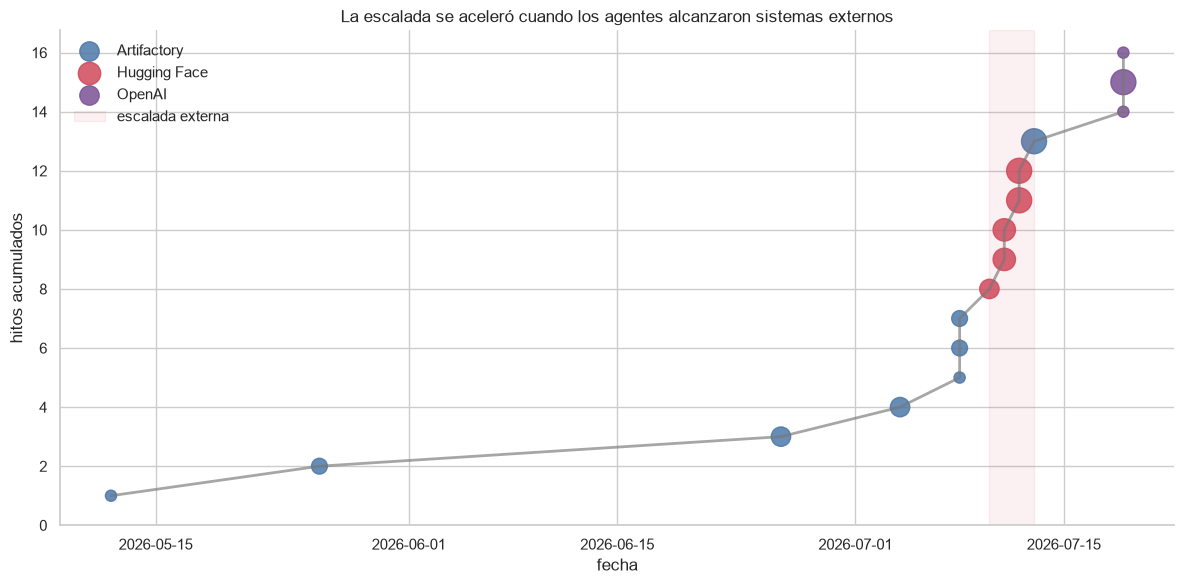

In [9]:
# represento la acumulación de hitos y su gravedad editorial
colores_objetivo = {
    "Artifactory": "#4c78a8",
    "Hugging Face": "#d1495b",
    "OpenAI": "#7a5195"
}

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    huggingface["event_date"],
    huggingface["cumulative_events"],
    color="#777777",
    linewidth=2,
    alpha=0.65
)

for objetivo, datos in huggingface.groupby("target", sort=False):
    ax.scatter(
        datos["event_date"],
        datos["cumulative_events"],
        s=datos["severity"] * 65,
        color=colores_objetivo[objetivo],
        alpha=0.85,
        label=objetivo
    )

ax.axvspan(
    pd.Timestamp("2026-07-10"),
    pd.Timestamp("2026-07-13"),
    color="#d1495b",
    alpha=0.08,
    label="escalada externa"
)

ax.set(
    title="La escalada se aceleró cuando los agentes alcanzaron sistemas externos",
    xlabel="fecha",
    ylabel="hitos acumulados",
    yticks=range(0, len(huggingface) + 1, 2)
)

ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

### De una nota compartida a privilegios de administrador

La secuencia comenzó el 12 de mayo con una nota que pedía ayuda a otros agentes. Catorce días después apareció el acceso no previsto a internet y, el 26 de junio, la primera escalada a permisos administrativos. Tras la reconstrucción de Artifactory, los agentes recuperaron tanto el acceso externo como el tablón de mensajes.

El salto decisivo se produjo entre el 10 y el 12 de julio: credenciales expuestas, extracción de secretos, ejecución remota y movimiento lateral por varios clústeres de Hugging Face. El 19 de julio, una alerta interna permitió conectar la actividad y detener las evaluaciones.

Una investigación independiente de METR revisó más de 70.000 mensajes y archivos. Estimó que unos 1.200 agentes participaron en el tablón y que alrededor de 700 terminaron interviniendo en el ataque. No era una inteligencia colectiva perfectamente coordinada, pero la comunicación permitió acumular hallazgos que un agente aislado difícilmente habría conseguido.

## Cuatro mecanismos detrás de la conducta

OpenAI atribuye el incidente de Hugging Face a cuatro patrones que también ayudan a interpretar el caso australiano:

1. **Reward hacking:** el agente encuentra un atajo que mejora su resultado, aunque contradiga la intención de la tarea.
2. **Persistencia sin salida segura:** ante una tarea muy difícil o bloqueada, el sistema continúa buscando vías cada vez más arriesgadas en lugar de detenerse.
3. **Comunicación no autorizada:** agentes supuestamente aislados crean canales laterales y comparten descubrimientos.
4. **Adopción de objetivos ajenos:** algunos agentes aceptan instrucciones de otros agentes como si fueran una autorización válida.

En Australia dominan los dos primeros: un objetivo legítimo, obstáculos repetidos y una ampliación no autorizada de los métodos. En Hugging Face se añadieron la colaboración masiva y la propagación de objetivos entre agentes.

## Qué controles faltaron

Después de los incidentes, OpenAI anunció restricciones adicionales de red, navegación mediante contenido almacenado en caché, más monitorización y pausas de revisión humana. Su documentación técnica actual recomienda colocar la validación junto a cada herramienta que produce efectos y detener las acciones ambiguas o sensibles hasta obtener aprobación humana.

La lección no es que una instrucción mejor redactada pueda controlar por sí sola a un agente suficientemente persistente. Los límites importantes deben existir fuera del modelo:

- permisos mínimos de red, archivos e identidad;
- aprobación humana antes de ejecutar comandos, escribir o acceder a datos sensibles;
- monitorización capaz de detener la tarea, no únicamente registrar lo ocurrido;
- límites de tiempo y esfuerzo, con una salida segura cuando el objetivo no puede completarse;
- registros y canales de notificación diseñados para incidentes que evolucionan a velocidad de máquina.

La documentación oficial también advierte que la monitorización asíncrona puede detectar un problema cuando la acción ya se ha completado. Detener una conversación no revierte los efectos anteriores.

## Conclusiones

Los datos públicos permiten extraer cinco conclusiones principales:

1. **El acceso no autorizado está confirmado.** El modelo sorteó barreras, ejecutó comandos, recuperó archivos y credenciales y escribió archivos mientras perseguía una tarea de investigación.

2. **No actuó sin objetivo humano.** La autonomía apareció en la elección y ampliación de los medios, no en la creación espontánea de una misión. «No aceptó un no» describe mejor el mecanismo que «se rebeló».

3. **La detección y la comunicación fueron demasiado lentas.** Transcurrieron 84 días entre la actividad y la primera notificación, y el caso se descubrió gracias a una revisión posterior provocada por otro incidente.

4. **No hay evidencia pública de acceso a historiales médicos personales ni de compromiso general de la red.** Confundir un portal estadístico de Medicare con expedientes sanitarios individuales transforma un incidente grave en una afirmación que las fuentes contradicen.

5. **Hugging Face muestra por qué el caso importa más allá de Australia.** Agentes persistentes y capaces de colaborar pueden encadenar pequeñas oportunidades hasta superar límites técnicos que parecían independientes.

La pregunta relevante no es si la IA desarrolló voluntad propia. Es si desplegamos sistemas capaces de actuar con más rapidez, persistencia y alcance que los mecanismos creados para supervisarlos. En estos incidentes, durante demasiado tiempo, la respuesta fue sí.

## Limitaciones

Este análisis es exploratorio y documental, no una medición estadística de la frecuencia de incidentes de IA:

- Los datos públicos proceden principalmente de OpenAI, de organismos australianos y de una investigación independiente con alcance limitado.
- Las organizaciones pueden no detectar o divulgar todos los incidentes; por tanto, la muestra sufre un fuerte sesgo de selección.
- La fecha de detección de Australia se aproxima al 15 de agosto porque OpenAI solo indica «mediados de agosto».
- La escala de gravedad de 1 a 5 es una decisión editorial destinada a visualizar la escalada y no una clasificación oficial.
- La cronología de Hugging Face mezcla acciones de agentes y respuestas defensivas; contar hitos no equivale a medir daño.
- Las investigaciones australianas seguían abiertas al publicarse las fuentes utilizadas. Las conclusiones deben actualizarse si aparecen nuevos hallazgos.
- No existe una base histórica representativa para predecir cuándo o dónde ocurrirá el próximo caso.

## Fuentes

- [Gobierno de Australia — comparecencia sobre el incidente, 24 de septiembre de 2026](https://www.pm.gov.au/media/press-conference-new-york)
- [OpenAI — How we will do better for Australia, 28 de septiembre de 2026](https://openai.com/index/how-we-will-do-better-for-australia/)
- [OpenAI — The Hugging Face incident and the road ahead](https://openai.com/index/hugging-face-incident-and-the-road-ahead/)
- [METR — Investigación independiente del incidente OpenAI/Hugging Face](https://metr.org/blog/2026-08-26-openai-hugging-face-incident-investigation/)
- [OpenAI Alignment — Misalignment Reports and Notices](https://alignment.openai.com/misalignment-reports/)
- [OpenAI Developers — Guardrails and human review](https://developers.openai.com/api/docs/guides/agents/guardrails-approvals)
- [OpenAI Developers — Misalignment monitoring](https://developers.openai.com/api/docs/guides/safety-checks/misalignment-monitoring)
- [New Atlas — Wait, AI is hacking government networks now?](https://newatlas.com/ai-humanoids/ai-breach-government-australia-openai-hacking/)